В цьому домашньому завданні ми реалізуємо логістичну регресію на `numpy`.
Ці завдання допоможуть вам ґрунтовно засвоїти основні концепції логістичної регресії та реалізувати їх на практиці 🔥

#### Завдання 1: Реалізація функції сигмоїди
1. З використанням `numpy` напишіть функцію `sigmoid(z)` для обчислення значення сигмоїди згідно з формулою:
   $$
   \sigma(z) = \frac{1}{1 + e^{-z}}
   $$
2. Використовуючи цю функцію, обчисліть значення сигмоїди для наступних даних: $ z = [-2, -1, 0, 1, 2] $. Виведіть результат обчислень.


In [41]:
import numpy as np

In [42]:
def sigmoid(z):
  return 1/(1 + np.exp(-z))

In [43]:
z = np.array([-2, -1, 0, 1, 2])

print(f'Значення сигмоїди для даних: {np.round(sigmoid(z), 2)}')

Значення сигмоїди для даних: [0.12 0.27 0.5  0.73 0.88]




#### Завдання 2: Реалізація функції гіпотези для логістичної регресії
1. Напишіть функцію `hypothesis(theta, X)`, яка обчислює гіпотезу для логістичної регресії, використовуючи функцію сигмоїди. Формула гіпотези:
   $$
   h_\theta(x) = \sigma(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}
   $$
2. Використайте функцію `hypothesis` для обчислення значень гіпотези для наступних даних:
   
   $\theta = [0.5, -0.5]$
   
   $X = \begin{bmatrix} 1 & 2 \\ 1 & -1 \\ 1 & 0 \\ 1 & 1 \end{bmatrix}$

  Виведіть результат обчислень.


In [44]:
def hypothesis(theta, X):
  z = np.dot(X, theta)
  # z = X.dot(theta) #v2
  return sigmoid(z)

In [45]:
theta = np.array([0.5, -0.5])
X = np.array([
    [1, 2],
    [1, -1],
    [1, 0],
    [1, 1]
])

result = hypothesis(theta, X)

print(f"Результат гіпотези: {result}")

Результат гіпотези: [0.37754067 0.73105858 0.62245933 0.5       ]


#### Завдання 3: Реалізація функції для підрахунку градієнтів фукнції втрат
1. Напишіть функцію `compute_gradient(theta, X, y)`, яка обчислює градієнти функції втрат для логістичної регресії. Формула для обчислення градієнта:
   $$
   \frac{\partial L(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left[ (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)} \right]
   $$
2. Використайте функцію `compute_gradient` для обчислення градієнтів для наступних даних:

  $\theta = [0.5, -0.5]$

  $X = \begin{bmatrix} 1 & 2 \\ 1 & -1 \\ 1 & 0 \\ 1 & 1 \end{bmatrix}$

  $y = [1, 0, 1, 0]$

  Виведіть результат обчислень.

In [46]:
def compute_gradient(theta, X, y):
  m = len(y)
  gradient = (1/m) * X.T.dot(hypothesis(theta, X) - y)
  return gradient


In [47]:
y = np.array([1, 0, 1, 0])

res_gradient = compute_gradient(theta, X, y)

print(f"Результат обчислень: {res_gradient}")

Результат обчислень: [ 0.05776464 -0.36899431]



#### Завдання 4: Реалізація повного батч градієнтного спуску

**Задача:**
1. Напишіть функцію `full_batch_gradient_descent(X, y, lr=0.1, epochs=100)`, яка реалізує алгоритм Full градієнтного спуску для логістичної регресії. Використовуйте такі формули:
   - Гіпотеза: $ h_\theta(x) = \sigma(\theta^T x) $
   - Оновлення параметрів: $ \theta_j := \theta_j - \alpha \frac{\partial L(\theta)}{\partial \theta_j} $
2. Використайте функцію `full_batch_gradient_descent` для обчислення параметрів моделі на наступних даних:

  $X = \begin{bmatrix} 1 & 2 \\ 1 & -1 \\ 1 & 0 \\ 1 & 1 \end{bmatrix}$

  $y = [1, 0, 1, 0]$

  Увага! Матриця $X$ вже має стовпець одиниць і передбачається, що це. - стовпець для intercept - параметра зсуву.

  Виведіть результат обчислень.


Результат обчислень: [-0.2893693   0.77655125]. Final loss: 0.59.


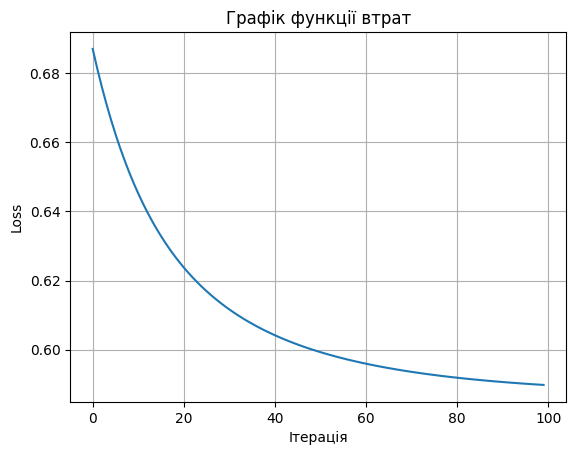

In [53]:
def full_batch_gradient_descent(X, y, lr=0.1, epochs=100):
    """
    Full-Batch градієнтний спуск для логістичної регресії
    X це матриця ознак (m, n+1)
    y це вектор міток (m,)
    lr це learning rate
    epochs це кількість ітерацій
    """

    theta = np.zeros(X.shape[1])  # початкові параметри = 0
    losses = []

    for _ in range(epochs):
        # Оновлення параметрів
        gradient = compute_gradient(theta, X, y)
        theta = theta - lr * gradient

        # Зберігаємо loss для графіку
        h = hypothesis(theta, X)
        loss = -np.mean(y * np.log(h) + (1 - y) * np.log(1 - h))
        losses.append(loss)

    return {"theta": theta, "losses": losses}

result = full_batch_gradient_descent(X, y, lr=0.1, epochs=100)
theta_final = result["theta"]
losses = result["losses"]

print(f"Результат обчислень: {theta_final}. Final loss: {losses[-1]:,.2f}.")

# Графік loss
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel('Ітерація')
plt.ylabel('Loss')
plt.title('Графік функції втрат')
plt.grid(True)
plt.show()

#### Завдання 5. Обчислення точності моделі

1. Напишіть функцію `predict_proba(theta, X)`, яка використовує знайдені параметри $\theta$ для обчислення ймовірностей належності поточного прикладу з даних до класу $y=1$ на основі значень $\sigma(\theta^T x)$.

2. Напишіть функцію `predict(theta, X, threshold=0.5)`, яка обчислює клас з передбаченої імовірності належності екземпляра до класу 1 з порогом 0.5. Тобто якщо ймовірність менше 0.5, то передбачаємо клас 0, інакше клас 1.

3. Напишіть функцію `accuracy(y_true, y_pred)`, яка обчислює точність моделі, визначивши частку правильно передбачених класів.

  Формула метрики Accuracy:
  $$
  \text{Accuracy} = \frac{\sum_{i=1}^{m} I(\hat{{y}^{(i)}} = y^{(i)})}{m}
  $$

  де $\hat{{y}^{(i)}}$ - передбачене значення класу, $I$ - індикаторна функція (яка дорівнює 1, якщо умова виконується, і 0 - якщо ні), $m$ - кількість прикладів.

4. Обчисліть з використанням даних в завданні 4 $X$, $y$ та обчислених коефіцієнтах $\theta$ та виведіть на екран:
  - передбачені моделлю імовірності належності кожного з екземплярів в матриці `X` до класу 1
  - класи кожного екземпляра з матриці `X`
  - точність моделі.

In [54]:
def predict_proba(theta, X):
  '''
   функція
   для обчислення ймовірностей належності поточного прикладу з даних
   до класу  y=1  на основі значень  σ(θTx)
  '''
  return hypothesis(theta, X)

print(f"Ймовірності належностіданих до класу 1: {predict_proba(theta_final, X)}.")

Ймовірності належностіданих до класу 1: [0.77966809 0.25617965 0.42815828 0.61944235].


In [55]:
def predict(theta, X, threshold=0.5):
  prob = predict_proba(theta, X)
  return (prob >= threshold).astype(int)

In [56]:
def accuracy(y_true, y_pred):
  return np.mean(y_true == y_pred)

In [58]:
probs4 = predict_proba(theta_final, X)
classes = predict(theta_final, X)
acc4 = accuracy(y, classes)

# outputs
print(f"Ймовірності належності до класу 1: {probs4}")
print(f"Передбачені класи: {classes}")
print(f"Точність моделі: {acc4}")

Ймовірності належності до класу 1: [0.77966809 0.25617965 0.42815828 0.61944235]
Передбачені класи: [1 0 0 1]
Точність моделі: 0.5
